In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import special

In [3]:
import scienceplots
plt.style.use("science")

%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi']=120 #default is 72. 

In [4]:
prob_data = pd.read_csv("survival_probability_new.csv",sep=",")

x= prob_data["x (L/E)"]
P_ee= prob_data["P_ee"]
P_ee_err= prob_data["P_ee_err"]

prob_data.head()

,x (L/E),P_ee,P_ee_err_min,P_ee_err_max,P_ee_err
0,23.261848,0.588141,0.528376,0.649788,0.121412
1,28.602149,0.639309,0.585662,0.695780,0.110118
2,30.937424,0.687725,0.629842,0.748901,0.119059
3,32.780057,0.866976,0.795917,0.935682,0.139765
4,34.497508,0.722935,0.662700,0.783642,0.120941


In [16]:
prob_data["P_ee_err"]=(prob_data["P_ee_err_max"]-prob_data["P_ee"])*2

In [18]:
P_err= prob_data["P_ee_err"]

### Parameter reconstruction for Vacuum mass hypothesis

The neutrino oscillation probability ($P_{ee}$) for vacuum mass hypothesis is as follows:

Vacuum survival probability:
$$P_{ee} = 1 - \cos^{4}\theta_{13}\, \sin^{2} 2\theta_{12}\,\sin^{2}\left( 1.27\,\frac{\Delta m_{21}^{2}\,L}{E_\nu}
\right) - \sin^{2} 2\theta_{13}\ .$$


In [19]:
param_names = [r'$\Delta m^{2}_{21}$', r'$\theta_{12}$', r'$\theta_{13}$']

In [20]:
import scipy.stats

def my_prior_transform(cube): # The prior list for parameters
    params = cube.copy()

    # dm21 varies between [1-15]* 10^(-5) eV^2
    hi= 15
    lo= 1
    params[0] = (cube[0] * (hi - lo) + lo) #*10**(-5)

    # theta_12 varies within [0-1]
    params[1] = cube[1]

    # theta_13 varies within [0-1]
    params[2] = cube[2]

    return params

In [21]:
from numpy import log

def my_likelihood(params):
    dm21, theta12, theta13 = params
    
    # L = 180 #km
    # E = 5 #MeV
    
    # compute intensity at every x position according to the model
    P_ee_vac = 1 - np.cos(theta13)**4 * np.sin(2*theta12)**2 * np.sin(1.27*dm21*x* 10**(-2)) - np.sin(2*theta13)**2
    
    # compare model and data with gaussian likelihood:
    chi2 = np.sum(((P_ee_vac - P_ee)/P_err)**2)
    like = -0.5 * chi2
    return like

In [22]:
import ultranest

sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, my_prior_transform)

In [23]:
result = sampler.run(show_status=False, viz_callback=None)
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...
[ultranest] Explored until L=-4  
[ultranest] Likelihood function evaluations: 13770
[ultranest]   logZ = -12.38 +- 0.07969
[ultranest] Effective samples strategy satisfied (ESS = 2084.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.08, need <0.5)
[ultranest]   logZ error budget: single: 0.13 bs:0.08 tail:0.01 total:0.08 required:<0.50
[ultranest] done iterating.

logZ = -12.379 +- 0.140
  single instance: logZ = -12.379 +- 0.125
  bootstrapped   : logZ = -12.384 +- 0.139
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    $\Delta m^{2}_{21}$ : 1.0   │▁▁▁▁▁▁▁           ▁    ▁▁▁▁▁▃▆▇▇▄▂▁▁▁▁ │15.0      11.7 +- 1.7
    $\theta_{12}$       : 0.000 │▁▁▁▁▁▁▁▁▁▁▁▂▄▅▇▇▇▆▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁ │0.546     0.219 +- 0.044
    $\theta_{13}$       : 0.000 │▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁

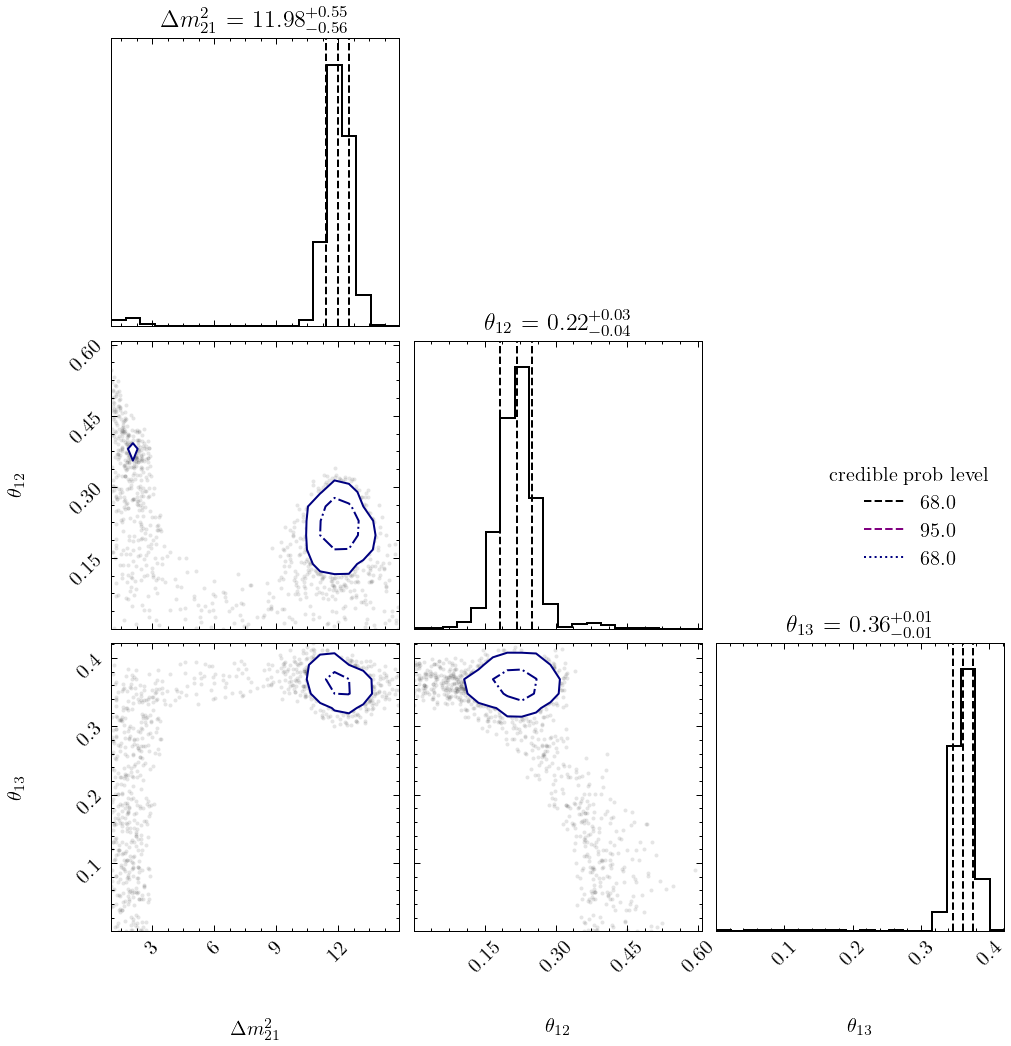

In [24]:
from ultranest.plot import cornerplot
fig= cornerplot(result,
                plot_datapoints=True, 
                levels=[0.68, 0.95],
                quantiles=[0.16, 0.5, 0.84],
                # show_titles=False,
                color='black',
                # plot_contour_labels=False
               );

# plt.tight_layout()
# plt.legend().remove()

plt.show()